# Приступим к работе

## Определим задачи для анализа текста  

**Задача:** Нужно проанализировать набор текстов, представленных в Word-формате и определить схожесть их содержания между собой. Такая программа позволит выявить плагиат среди схожих работ, проектов, статей и записок.  

**Цель:** Разработать обученную модель, которая будет автоматически обрабатывать и анализировать текстовые данные, выявлять плагиат среди работ, сравнивая документы по содержанию, тематике, выделяя ключевые особенности.  

**Методы:** В ходе выполнения работы будут использоваться методы обработки естественного языка (NLP), включая предобработку текста, его нормальзацию, векторизацию, фильтрацию (используя методы: мешок слов, TF-IDF), а также различные другие методы машинного обучения для того, чтобы класстеризировать документы.  


Таким образом, работа заключается в кластеризации и классификации документов.  

Используемые материалы: текстовые данные из записок курсовых работ, а также данные из датасета.  

Цель: Построить модель класстеризации и классификации текстов.

## Выгрузка данных и ресурсов из записок

In [115]:
import os

import pandas as pd
import spacy
from docx import Document
from docx.document import Document as DocumentType
from pandas import DataFrame


# Чтение текста из файла
def read_docx(file_path: str) -> str:
    # Считывает текст из файла .docx
    try:
        if not os.path.isfile(file_path):
            raise FileNotFoundError(f"Файл {file_path} не найден")

        document = Document(file_path)
        full_text: list[str] = [paragraph.text.strip() for paragraph in document.paragraphs if paragraph.text.strip()]
        return "\n".join(full_text)
    
    except Exception as e:
        print(f"Ошибка при чтении {file_path}: {e}")
        return ""

# Загрузка текста из файлов
def load_docx(dataset_path: str) -> DataFrame:
    # Загружает документы из уазанной директории в DataFrame
    if not os.path.isdir(dataset_path):
        raise NotADirectoryError(f"Директория {dataset_path} не найдена")

    documents = []
    for file_name in sorted(os.listdir(dataset_path)):
        if file_name.startswith("~$") or not file_name.lower().endswith(".docx"):
            continue
        file_path = os.path.join(dataset_path, file_name)
        text = read_docx(file_path)
        if text:
            doc_type = 0 if file_name.startswith("tz_") else 1
            documents.append((file_name, text, doc_type))
        
    df = pd.DataFrame(documents, columns=["doc", "text", "type"])
    df.sort_values(by="doc", inplace=True)
    return df
    

# Пути
project_root = os.path.abspath(os.getcwd())
# project_root: str = os.path.abspath(os.path.join(os.path.dirname("lab8.ipynb"), ".."))
dataset_path: str = os.path.join(project_root, "static", "pmu")

# Загрузка данных
try:
    df = load_docx(dataset_path)
    df.info()

    # Вывод первых строк данных
    display(df.head())
except Exception as e:
    print(f"Ошибка загрузки данных: {e}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   doc     58 non-null     object
 1   text    58 non-null     object
 2   type    58 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.5+ KB


,doc,text,type
0,31-АнисинРС.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1
1,31-АфанасьевСС.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1
2,31-БакальскаяЕД.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1
3,31-БарсуковПО.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1
4,31-БелянинНН.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1


## Предообработка текста  

Предобработка текста и применение к каждому документу   

**Предобработка текста** - это процесс преобразования неструктурированного текста в структурированный для подготовки его к анализу. Также является важнейшим этапом в задачах обработке естественного языка (Natural Language Processing - NLP), который включает подготовку текстовых данных для дальнейшего анализа или использования в моделях машинного обучения.

Предобработка текста представляет собой выполнение следующих шагов:  
1. *Изменение регистра:* приведение текста к нижнему регистру.
2. *Применение регулярного выражения:* удаление всех символов, кроме букв и пробелов.
3. *Удаление диакритических знаков:* нормализация текста с использованием метода unicodedata.
4. *Преобразование чисел в строку:* использование библиотеки num2words.
5. *Токенизация:* процесс разбиения текста на отдельные элементы (токены), такие как слова, фразы или символы.
6. *Нормализация:* приведение текста к единому формату для упрощения обработки. Подобная унификация позволяет уменьшить вариативность данных и упростить анализ.
7. *Удаление стоп-слов (Stop Words Removal):* удаление часто встречающихся слов, которые не несут смысловой нагрузки ("и", "в", "на"). Всё это нужно для уменьшения шума в данных и упрощения анализа.
8. *Лемматизация и стемминг:* упрощение анализа текста за счёт приведения слов к единой форме. Лемматизация - приведение слов к его начальной форме (лемме). Стемминг - обращение слова до его корня (менее точный чем лемматизация).
9. *Удаление пунктуации и специальных символов:* удаление знаков препинания, цифр, эмодзи и других символов, которые не несут смысловой нагрузки. (Для уменьшения шума в данных и упрощения анализа).
10. *Обработка редких опечаток:* исправление опечаток и замена редких слов на специальные токены. (Для улучшения качества данных и уменьшение шума).
11. *Векторизация текста:* преобразование текста в числовой формат, который может быть использован в моделях машинного обучения. Алгоритмы МО работают с числами, а не с символами. Основные методы:  

Bag of Words (BoW) — представление текста в виде вектора частот слов.  
TF-IDF — учет важности слов в тексте.  
Word Embeddings (например, Word2Vec, GloVe, FastText) — представление слов в виде плотных векторов.  
Токенизация для моделей на основе трансформеров (например, BERT, GPT) — преобразование текста в последовательность токенов.  

12. *Удаление дубликатов:* удаление повторяющихся текстовых данных для уменьшения объёма данных и устранения избыточности.
13. *Сегментация данных:* разделение текста на предложения и абзацы для упрощения анализа текста и подготовка данных для моделей, работающих с предложениями.
14. *Обработка специфических данных:* удаление HTML-тегов, эмодзи, хэштегов, упоминаний и других специфических элементов для уменьшения шума в данных и упрощения анализа.


In [ ]:
import nltk
import re
import unicodedata
from typing import Set

from num2words import num2words
from nltk.corpus import stopwords
from spacy.tokens.doc import Doc

# Необходимо скачать модель
# python -m spacy download ru_core_news_lg

# Загрузка модели Spacy. Модель для русского языка
spacy = spacy.load("ru_core_news_lg")

# Загрузка модели для русского языка. 
# nlp = spacy.load("ru_core_news_lg")

nltk.download("punkt")
nltk.download("stopwords")
stop_woards = set(stopwords.words("russian"))

# Список стоп-слов 
stop_woards: Set[str] = spacy.Defaults.stop_words

# Предобработка текста. Метод для предобработки текста
def preprocess_text(text):
    # Приведение текста к нижнему регистру
    text = text.lower()
    
    # Замена переносов на пробел
    text = text.replace("\n", " ")
    
    # Удаление всех символов, кроме букв и пробелов
    text = re.sub(r"[^a-zA-Za-яА-Я ]", "", text)

    # Удаление диакритических знаков
    text = unicodedata.normalize("NFKD", text)
    text = "".join([char for char in text if not unicodedata.combining(char)])

    # Преобразование чисел в слова
    words: list[str] = text.split()
    words = [num2words(word, lang="ru") if word.isdigit() else word for word in words]
    text = " ".join(words)

    # Токенизация с использованием Spacy
    document = spacy(text)

    # Удаление стоп-слов и пунктуации
    tokens = [token.text for token in document if token.text not in stop_woards and not token.is_stop 
              and not token.is_punct and not token.is_digit]
    
    return " ".join(tokens)


# Применение метода предобработки к загруженному тексту в DataFrame
df["preprocessed_text"] = df["text"].apply(preprocess_text)

# Вывод первых строк DataFrame с предобработанными текстами
display(df.head())

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\nikbe\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nikbe\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,doc,text,type,preprocessed_text
0,31-АнисинРС.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...
1,31-АфанасьевСС.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...
2,31-БакальскаяЕД.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...
3,31-БарсуковПО.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...
4,31-БелянинНН.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...


## Нормализация текста (Лемматизация и Стемминг)  

**Нормализация текста** - это процесс приведения текста к единому стандартному виде (форму). В данном случае используется метод лемматизации.

**Лемматизация** - это процесс приведения слова к его начальной форме (лемме).  

**Стемминг (Стеммер Портера)** - обращение слова до его корня (менее точный чем лемматизация).

In [117]:
from nltk.stem import PorterStemmer

# Функция Стемминга текста
def stemming_text(text: str) -> str:
    stemmer = PorterStemmer()
    stemmed_word = [stemmer.stem(word) for word in text.split()]
    return " ".join(stemmed_word)

# Функция Лемматизации текста
def lemmatization_text(text: str) -> str:
    doc = spacy(text)
    lemmas = [token.lemma_ for token in doc if not token.is_punct and not token.is_space]
    return " ".join(lemmas)


# Применение метода предобработки к каждому тексту в DataFrame
df["stemming_text"] = df["preprocessed_text"].apply(stemming_text)
df["lemmatized_text"] = df["preprocessed_text"].apply(lemmatization_text)

# Вывод первых строк DataFrame с предобработанными текстами
display(df.head())

,doc,text,type,preprocessed_text,stemming_text,lemmatized_text
0,31-АнисинРС.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...,министерство науки высшего образования россиис...,министерство наука высокий образование россиис...
1,31-АфанасьевСС.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...,министерство науки высшего образования россиис...,министерство наука высокий образование россиис...
2,31-БакальскаяЕД.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...,министерство науки высшего образования россиис...,министерство наука высокий образование россиис...
3,31-БарсуковПО.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...,министерство науки высшего образования россиис...,министерство наука высокий образование россиис...
4,31-БелянинНН.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...,министерство науки высшего образования россиис...,министерство наука высокий образование россиис...


## Фильтрация текста  

**Фильтрация текста** - сокращение пространства признаков за счёт удаления слов по определённым условиям.

In [118]:
# Функция фильтрации текста
def filter_text(text: str, min_length: int = 3, max_length: int = 15) -> str:
    words = text.split()

    # Удаление слов, где длина либо меньше минимального, либо больше
    return " ".join(word for word in words if min_length <= len(word) <= max_length)

# Применение фильтрации к лемматизированным текстам
df["filtered_text"] = df["lemmatized_text"].apply(filter_text)

# Вывод первых строк DataFrame с отфильтрованными текстами
display(df.head())

,doc,text,type,preprocessed_text,stemming_text,lemmatized_text,filtered_text
0,31-АнисинРС.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...,министерство науки высшего образования россиис...,министерство наука высокий образование россиис...,министерство наука высокий образование россиис...
1,31-АфанасьевСС.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...,министерство науки высшего образования россиис...,министерство наука высокий образование россиис...,министерство наука высокий образование россиис...
2,31-БакальскаяЕД.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...,министерство науки высшего образования россиис...,министерство наука высокий образование россиис...,министерство наука высокий образование россиис...
3,31-БарсуковПО.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...,министерство науки высшего образования россиис...,министерство наука высокий образование россиис...,министерство наука высокий образование россиис...
4,31-БелянинНН.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...,министерство науки высшего образования россиис...,министерство наука высокий образование россиис...,министерство наука высокий образование россиис...


## Морфологический анализ (POS tagging)  

**Морфологическиий анализ** - это определение грамматических характеристик слов, процесс выделения частей речи. Это позволяет понять структуру слова и его роль в предложении:  

К каждому слову текста можно подобрать множество морфологических признаков: часть речи, падеж род, число, одушевлённость.  

Этапы морфологического анализа:  
1. Токенизация
2. Определение части речи
3. Определение грамматических характеристик
4. Лемматизация  

Выделение частей речи

In [119]:
# Функция для морфологического анализа  
def morphological_analysis(text: str) -> list[dict]:
    document = spacy(text)
    # Сбор информации о каждом токене: текст, лемма, часть речи, морфологические признаки
    tokens_info: list[dict] = [
        {
            "text": token.text,
            "lemma": token.lemma_,
            "pos": token.pos_,
            "morph": token.morph,

        }
        for token in document
    ]
    
    return tokens_info


# Применение морфологического анализа к отфильтрованным текстам
df["morphological_info"] = df["filtered_text"].apply(morphological_analysis)

# Вывод строк DataFrame с морфологическим анализом
display(df.head())

,doc,text,type,preprocessed_text,stemming_text,lemmatized_text,filtered_text,morphological_info
0,31-АнисинРС.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...,министерство науки высшего образования россиис...,министерство наука высокий образование россиис...,министерство наука высокий образование россиис...,"[{'text': 'министерство', 'lemma': 'министерст..."
1,31-АфанасьевСС.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...,министерство науки высшего образования россиис...,министерство наука высокий образование россиис...,министерство наука высокий образование россиис...,"[{'text': 'министерство', 'lemma': 'министерст..."
2,31-БакальскаяЕД.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...,министерство науки высшего образования россиис...,министерство наука высокий образование россиис...,министерство наука высокий образование россиис...,"[{'text': 'министерство', 'lemma': 'министерст..."
3,31-БарсуковПО.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...,министерство науки высшего образования россиис...,министерство наука высокий образование россиис...,министерство наука высокий образование россиис...,"[{'text': 'министерство', 'lemma': 'министерст..."
4,31-БелянинНН.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...,министерство науки высшего образования россиис...,министерство наука высокий образование россиис...,министерство наука высокий образование россиис...,"[{'text': 'министерство', 'lemma': 'министерст..."


## Формирование N-грамм  

**N-грамма** - это процесс разбиения текста на последовательности из N слов (или символов, или букв, или слов). N-граммы широко используются в задачах обработки естественного языка (NLP), таких как анализ текста, машинный перевод, генерация текста и классификация.

*Виды N-грамм:*
1. Униграммы (Unigrams, N = 1) - последовательности из одного элемента (слова).  
2. Биграммы (Bigrams, N = 2) - последовательности из двух элементов.  
3. Триграммы (Trigrams, N = 3) - последовательности из трёх элементов.  
4. N-граммы (для N > 3) - последовательности из N элементов.  

N-граммы позволяют анализировать и учитывать контекст слов. Биграммы выявляют схожесть слов друг с другом. Классификация текста по признакам (тематика, тональность и тд.). Поиск шаблонов и встречающихся последовательностей слов и символов. Построение языковых моделей, которые предсказывают следующее слово в последовательности (автодополнение).  

Для формирования N-грамм будем использовать библиотеку nltk.  

Помимо этого N-граммы можно формировать не только из слов, но и из символов, что пригодиться в задачах, связанных с анализом последовательностей символов (анализ DNA, автокоррекция)

In [120]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize


# Загрузка ресурсов для токенизации
nltk.download("punkt")
nltk.download("punkt_tab")


def generate_ngrams(text: str, n: int = 2) -> list[tuple]:
    # Токенизация текста
    tokens = word_tokenize(text, language="russian")

    # Формирование N-грамм
    n_grams: list[tuple] = list(ngrams(tokens, n))
    return n_grams

# Для униграммы (N=1)
df["unigrams"] = df["filtered_text"].apply(lambda x: generate_ngrams(x, n=1))

# Для биграмм (N=2)
df["bigrams"] = df["filtered_text"].apply(lambda x: generate_ngrams(x, n=2))

# Для триграмм (N=3)
df["trigrams"] = df["filtered_text"].apply(lambda x: generate_ngrams(x, n=3))

# Вывод первых строк DataFrame с N-граммами
display(df.head())

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\nikbe\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\nikbe\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,doc,text,type,preprocessed_text,stemming_text,lemmatized_text,filtered_text,morphological_info,unigrams,bigrams,trigrams
0,31-АнисинРС.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...,министерство науки высшего образования россиис...,министерство наука высокий образование россиис...,министерство наука высокий образование россиис...,"[{'text': 'министерство', 'lemma': 'министерст...","[(министерство,), (наука,), (высокий,), (образ...","[(министерство, наука), (наука, высокий), (выс...","[(министерство, наука, высокий), (наука, высок..."
1,31-АфанасьевСС.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...,министерство науки высшего образования россиис...,министерство наука высокий образование россиис...,министерство наука высокий образование россиис...,"[{'text': 'министерство', 'lemma': 'министерст...","[(министерство,), (наука,), (высокий,), (образ...","[(министерство, наука), (наука, высокий), (выс...","[(министерство, наука, высокий), (наука, высок..."
2,31-БакальскаяЕД.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...,министерство науки высшего образования россиис...,министерство наука высокий образование россиис...,министерство наука высокий образование россиис...,"[{'text': 'министерство', 'lemma': 'министерст...","[(министерство,), (наука,), (высокий,), (образ...","[(министерство, наука), (наука, высокий), (выс...","[(министерство, наука, высокий), (наука, высок..."
3,31-БарсуковПО.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...,министерство науки высшего образования россиис...,министерство наука высокий образование россиис...,министерство наука высокий образование россиис...,"[{'text': 'министерство', 'lemma': 'министерст...","[(министерство,), (наука,), (высокий,), (образ...","[(министерство, наука), (наука, высокий), (выс...","[(министерство, наука, высокий), (наука, высок..."
4,31-БелянинНН.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...,министерство науки высшего образования россиис...,министерство наука высокий образование россиис...,министерство наука высокий образование россиис...,"[{'text': 'министерство', 'lemma': 'министерст...","[(министерство,), (наука,), (высокий,), (образ...","[(министерство, наука), (наука, высокий), (выс...","[(министерство, наука, высокий), (наука, высок..."


## Векторизация с использованием мешка слов (BoW)  

**Векторизация текста** - это процесс преобразования текстовых данных в числовые векторы, которые используются для анализа и обработки данных в моделях машинного обучения.

**Метод мешка слов (Bag of Words, BoW)** - это простой и популярный способ векторизации текста. Основная идея BoW заключается в том, что текст представляется в виде "Мешка" (набора) уникальных слов без учёта их порядка и грамматики. Каждое слово связано с числом (сколько раз оно встречается в тексте) и рассматривается как отдельная характеристика. Текст же представляется в виде вектора, где каждый элемент соответствует частоте (или наличию) определённого слова.

In [121]:
from typing import Any, Union

from numpy import ndarray
from scipy import sparse
from scipy.sparse._matrix import spmatrix
from sklearn.feature_extraction.text import CountVectorizer

# Создадим объект от CountVectorizer
counter_vectorizer = CountVectorizer()

# Применяем векторизацию к текстам отфильтрованным
# counts_matrix = sparse.csr_matrix(counter_vectorizer.fit_transform(df["filtered_text"]))
counts_matrix: Union[ndarray[Any, Any], spmatrix] = counter_vectorizer.fit_transform(df["filtered_text"])

# Преобразуем результат в DataFrame для удобства
counter_df = pd.DataFrame(counts_matrix.toarray(), columns=counter_vectorizer.get_feature_names_out())

# Выводим первые строки результата
display(counter_df.head())

,abbreviated,abilities,aboba,about,abrath,abstract,acceleration,accent,accept,access,accidentally,according,accountid,accuses,across,act,action,actionparse,actionquery,actions,activate,activated,activating,active,activities,activitiesdto,activity,activitydatadto,activitydto,activitydtodart,activityrepo,activityscreen,activityword,add,addbutton,addconst,added,addhomeevent,adding,additional,...,этои,этой,эффект,эффекте,эффективней,эффективно,эффективнои,эффективность,эффективныи,эффективный,юзабилити,юзер,юмористическии,юнус,юриевич,ютуб,явление,являться,являющиися,ядро,язык,языкеанглиискии,языковой,языкурис,язычныи,якобчук,яковлев,янович,япония,японскои,яркии,яркий,яркооранжевым,ярлык,ярусин,ярускин,ярускина,ясно,ясный,яшин
0,0,0,0,0,0,8,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,2,0,0,1,...,0,0,0,0,0,1,0,2,0,1,0,0,0,0,0,1,0,3,0,0,15,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,0,1,...,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,6,0,0,22,0,0,0,0,0,0,0,0,0,1,4,0,0,0,0,0,0,0,0
2,0,0,0,0,0,9,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,7,0,0,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,6,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,0,1,...,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,5,0,0,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,5,0,0,0,0,0,0,0,0,0,0,3,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,...,2,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,7,0,0,22,0,2,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0


## Векторизация с использованием частотоного портрета (TF-IDF)  

**TF-IDF (Term Frequency-Inverse Document Frequency)** - это более продвинутый метод векторизации, который учитывает не только частоту слова в тексте, но и его важность в корпусе. Он состоит из двух компонентов:  

1. TF (Term Frequency) - частота слова в тексте.
2. IDF (Inverse Document Frequency) - обратная частота документа, которая уменьшает  


*TF-IDF векторизация* - это метод преобразования текстовых данных в числовые векторы. Term Frequency-Inverse Document Frequency - частота термина - Обратная частота документа.

In [122]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Создание объекта TfidVectorizer
tfidf_vectorizer = TfidfVectorizer(max_df=0.85, sublinear_tf=True)

# Применяем векторизацию к отфильтрованным фильтрам
tfidf_matrix: spmatrix = tfidf_vectorizer.fit_transform(df["filtered_text"])

# Преобразуем результат в DataFrame для удобства
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Вывод первые строки результата
display(tfidf_df.head())


,abbreviated,abilities,aboba,about,abrath,acceleration,accent,accept,access,accidentally,according,accountid,accuses,across,act,action,actionparse,actionquery,actions,activate,activated,activating,active,activities,activitiesdto,activity,activitydatadto,activitydto,activitydtodart,activityrepo,activityscreen,activityword,add,addbutton,addconst,added,addhomeevent,adding,additional,additionally,...,этап,этапе,этои,этой,эффект,эффекте,эффективней,эффективно,эффективнои,эффективность,эффективныи,эффективный,юзабилити,юзер,юмористическии,юнус,юриевич,ютуб,явление,являющиися,ядро,языкеанглиискии,языковой,языкурис,язычныи,якобчук,яковлев,янович,япония,японскои,яркии,яркий,яркооранжевым,ярлык,ярусин,ярускин,ярускина,ясно,ясный,яшин
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.020155,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.027249,0.0,0.0,0.022375,0.0,0.0,0.012984,0.025874,...,0.019069,0.000000,0.000000,0.0,0.0,0.0,0.0,0.013215,0.0,0.031593,0.0,0.017887,0.0,0.0,0.000000,0.0,0.0,0.022531,0.000000,0.0,0.0,0.0,0.019069,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.024000,0.0,0.0,0.011640,0.0,0.0,0.011436,0.022789,...,0.016796,0.021562,0.016088,0.0,0.0,0.0,0.0,0.000000,0.0,0.016435,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.019845,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.023694,0.069332,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.019358,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.026172,0.0,0.0,0.012693,0.0,0.0,0.012471,0.030803,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.042276,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.020774,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.028086,0.0,0.0,0.013621,0.0,0.0,0.013383,0.000000,...,0.046902,0.000000,0.000000,0.0,0.0,0.0,0.0,0.013621,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.041172,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.019009,0.0,0.0,0.0,0.034659,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.010056,0.0,0.0,0.000000,0.000000,...,0.014510,0.018628,0.023533,0.0,0.0,0.0,0.0,0.010056,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.024568,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.020470,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Неиерархическая кластеризация (K-Means)  

**K-Means** - это метод машинного обучения для кластеризации данных на основе разбиения векторного пространства на заранее определённое число кластеров k. Данный метод неиерархической кластеризации позволяет задать разделение данных на n класстеров (групп) на основе их близости к центроидам (центрам кластеров). Основная идея заключается в том, чтобы минимизировать суммарное квадратичное отклонение точек внутри кластера от его центра.  

In [123]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


# Реализуем кластеризацию, а затем вычислим sse (сумму квадратов ошибок) для разного числа кластеров
sse = []

max_clusters = 50 # Максимальное число кластеров
for k in range(1, max_clusters + 1):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(tfidf_matrix)
    sse.append(kmeans.inertia_)

# Визуализация кластеризации
df["cluster"] = kmeans.labels_
display(df[["doc", "cluster"]])

,doc,cluster
0,31-АнисинРС.docx,29
1,31-АфанасьевСС.docx,49
2,31-БакальскаяЕД.docx,12
3,31-БарсуковПО.docx,33
4,31-БелянинНН.docx,27
5,31-ЖирноваАЕ(1).docx,18
6,31-ИевлеваМД (1).docx,34
7,31-КозыревСС.docx,14
8,31-КрюковАИ (1).docx,1
9,31-КувшиновТА.docx,37


### Метод локтя  

**Метод локтя** - это популярный эвристический подход (нестандартное решение) для определения оптимального числа кластеров k в алгоритме K-Means. Он основывается на анализе инерции (суммы квадратов расстрояний внутри кластеров).  

*Принцип работы алгоритма:*
1. Вычисление инерции с помощью различных значений k вычисляется инерция W(k)
2. Построение графика зависимости инерции от числа кластеров k
3. Поиск "локтя": на графике ищется точка, где снижение инерции начинает замедляться. Эта точка и есть оптимальное количество кластеров.  

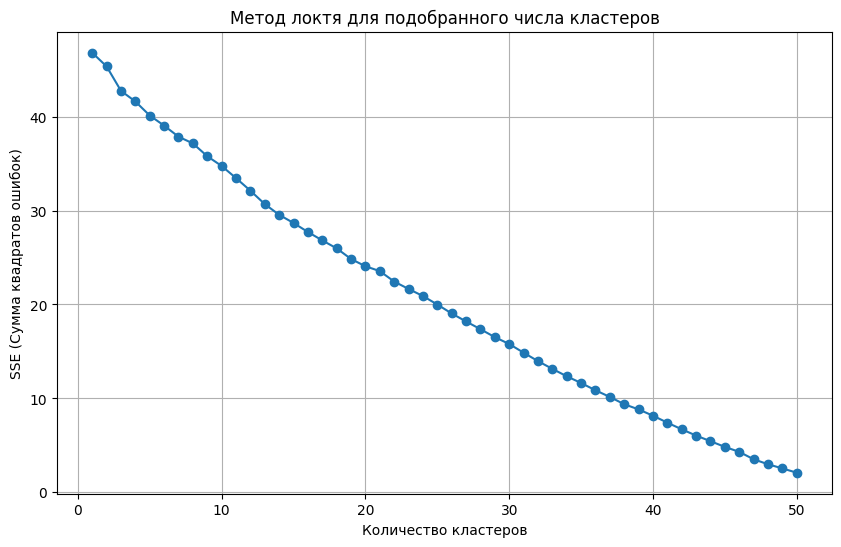

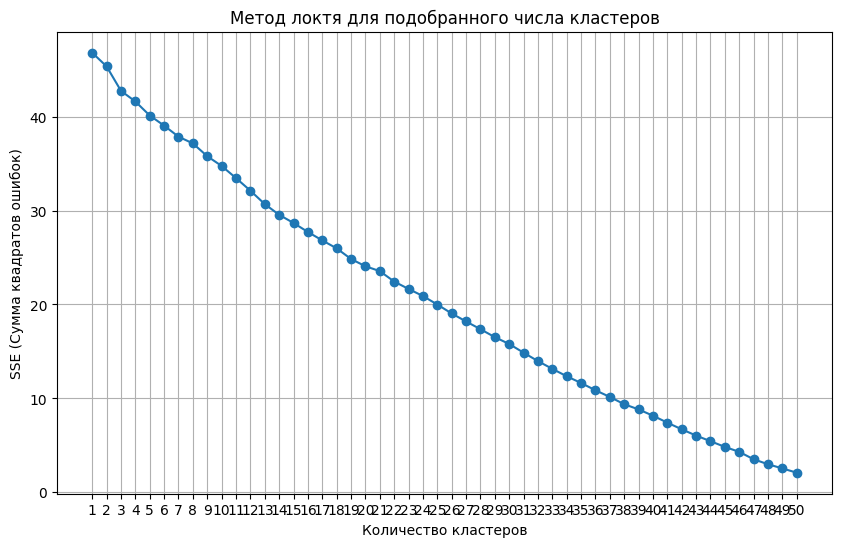

In [124]:
#  Визуализация метода локтя
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_clusters + 1), sse, marker="o")
plt.xlabel("Количество кластеров")
plt.ylabel("SSE (Сумма квадратов ошибок)")
plt.title("Метод локтя для подобранного числа кластеров")
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, max_clusters + 1), sse, marker="o")
plt.xlabel("Количество кластеров")
plt.ylabel("SSE (Сумма квадратов ошибок)")
plt.title("Метод локтя для подобранного числа кластеров")
plt.xticks(range(1, max_clusters + 1))
plt.grid()
plt.show()

Метод позволяет избежать переобучения и обеспечивает баланс между сложностью модели и качеством кластеризации.

### Коэффициент силуэта  

**Коэффициент силуэта** - это метрика, используемая для оценки качества кластеризации. Она измеряет, насколько хорошо объекты кластеризированы, учитывая как компактность кластеров (насколько близки объекты внутри одного кластера), так и разделимость (насколько далеко находятся объекты разных кластеров). Оценка варьируется от -1 до 1  

1 - объекты хорошо кластеризованы, далеко от других кластеров.  
0 - объекты на границе между кластерами.  
1 - объект, вероятно, неправильно классифицирован.  

*Коэффициент силуэта* рассчитывается по формуле `s(i) = b(i) - a(i) / max(a(i), b(i))`  
a(i) - среднее расстояние до объектов в том же кластере.  
b(i) - минимальное среднее расстояние до объектов в ближайшем кластере.  

Высокие значения указывают на хорошую кластеризацию, низкие - на проблемы с классификацией.

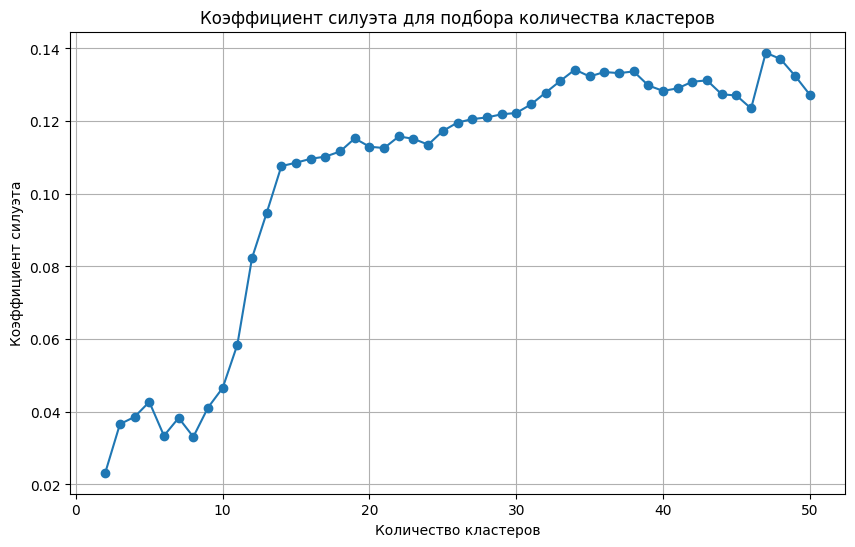

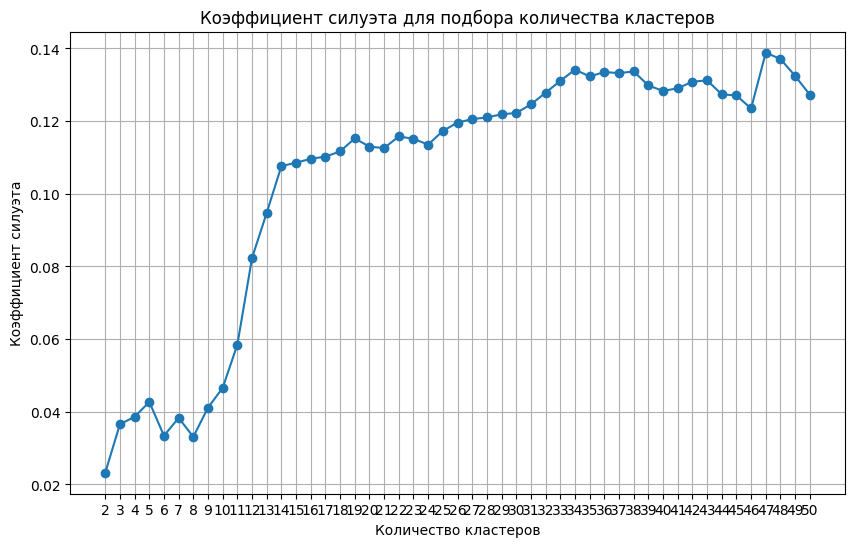

In [125]:
from sklearn.metrics import silhouette_score

# Вычислим коэффициент силуэта
silhouette_scores = []

# Минимум с двух кластеров начинаем
for k in range(2, max_clusters + 1):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(tfidf_matrix)
    score = silhouette_score(tfidf_matrix, kmeans.labels_, random_state=42)
    silhouette_scores.append(score)


# Визуализация коэффициента силуэта
plt.figure(figsize=(10, 6))
plt.plot(range(2, max_clusters + 1), silhouette_scores, marker="o")
plt.xlabel("Количество кластеров")
plt.ylabel("Коэффициент силуэта")
plt.title("Коэффициент силуэта для подбора количества кластеров")
plt.grid()
plt.show()

# Визуализация коэффициента силуэта
plt.figure(figsize=(10, 6))
plt.plot(range(2, max_clusters + 1), silhouette_scores, marker="o")
plt.xlabel("Количество кластеров")
plt.ylabel("Коэффициент силуэта")
plt.title("Коэффициент силуэта для подбора количества кластеров")
plt.xticks(range(2, max_clusters + 1))
plt.grid()
plt.show()

### Кластеризация с использованием K-Means

In [126]:
from sklearn.cluster import KMeans

# Задаём количество кластеров 27
n_clusters = 27
kmeans = KMeans(n_clusters=n_clusters, random_state=42)

# Обучаем модель на TF-IDF векторах
kmeans.fit(tfidf_matrix)

# Добавляем метки кластеров в DataFrame
df["cluster"] = kmeans.labels_

# Выводим документы с их кластерами
display(df[["doc", "cluster"]])

,doc,cluster
0,31-АнисинРС.docx,14
1,31-АфанасьевСС.docx,6
2,31-БакальскаяЕД.docx,12
3,31-БарсуковПО.docx,13
4,31-БелянинНН.docx,14
5,31-ЖирноваАЕ(1).docx,18
6,31-ИевлеваМД (1).docx,18
7,31-КозыревСС.docx,14
8,31-КрюковАИ (1).docx,1
9,31-КувшиновТА.docx,14


### Визуализация кластеров текстов с использованием PCA

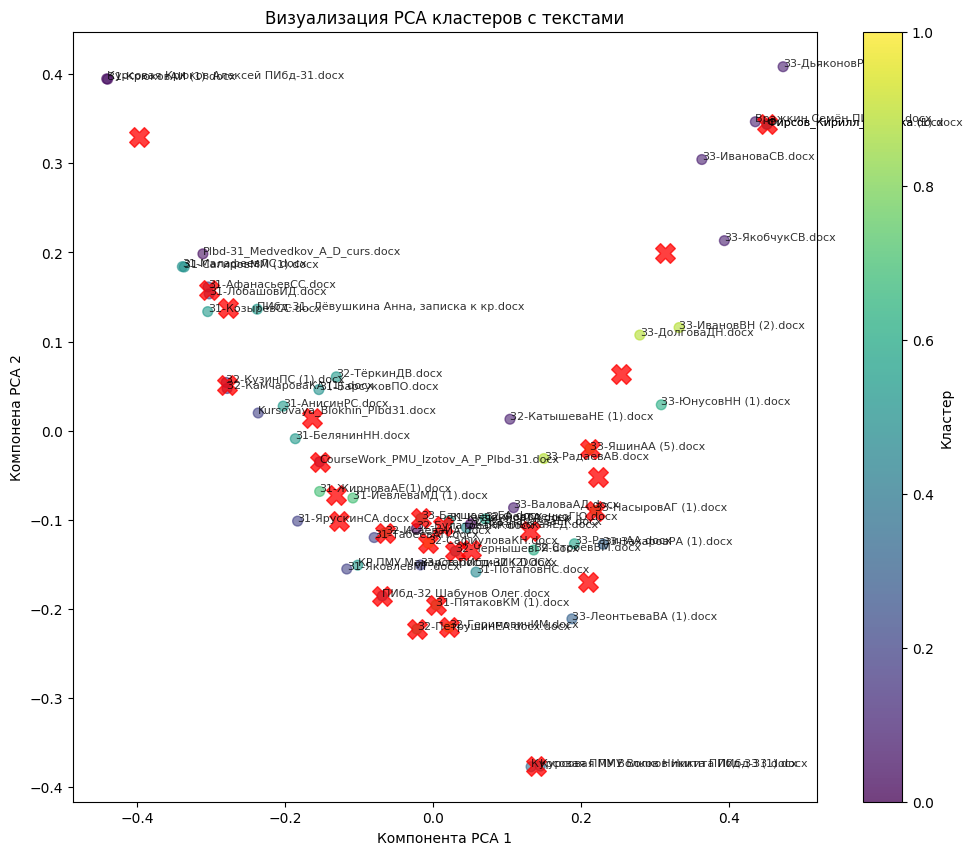

In [127]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Задаём количество кластеров
n_clusters = 27

# Создаём модель K-Means 
kmeans = KMeans(n_clusters=n_clusters, random_state=42)

# Обучаем модель и предсказываем кластеры
clusters = kmeans.fit_predict(tfidf_matrix)

# Уменьшаем размерность данных до 2 компонент с помощью PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(tfidf_matrix.toarray())

# Визуализируем кластеры
plt.figure(figsize=(12, 10))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap="viridis", s=50, alpha=0.6)

# Подписи для центроидов кластеров
centers = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], c="red", s=200, alpha=0.75, marker="X")

# Добавляем подписи для каждого документа
for i, document in enumerate(df["doc"]):
    plt.text(X_pca[i, 0], X_pca[i, 1], document, fontsize=8, alpha=0.8)

# Заголовок и подписи осей
plt.title("Визуализация PCA кластеров с текстами")
plt.xlabel("Компонента PCA 1")
plt.ylabel("Компонена PCA 2")
plt.colorbar(label="Кластер")
plt.show()

### Отображение результата кластеризации

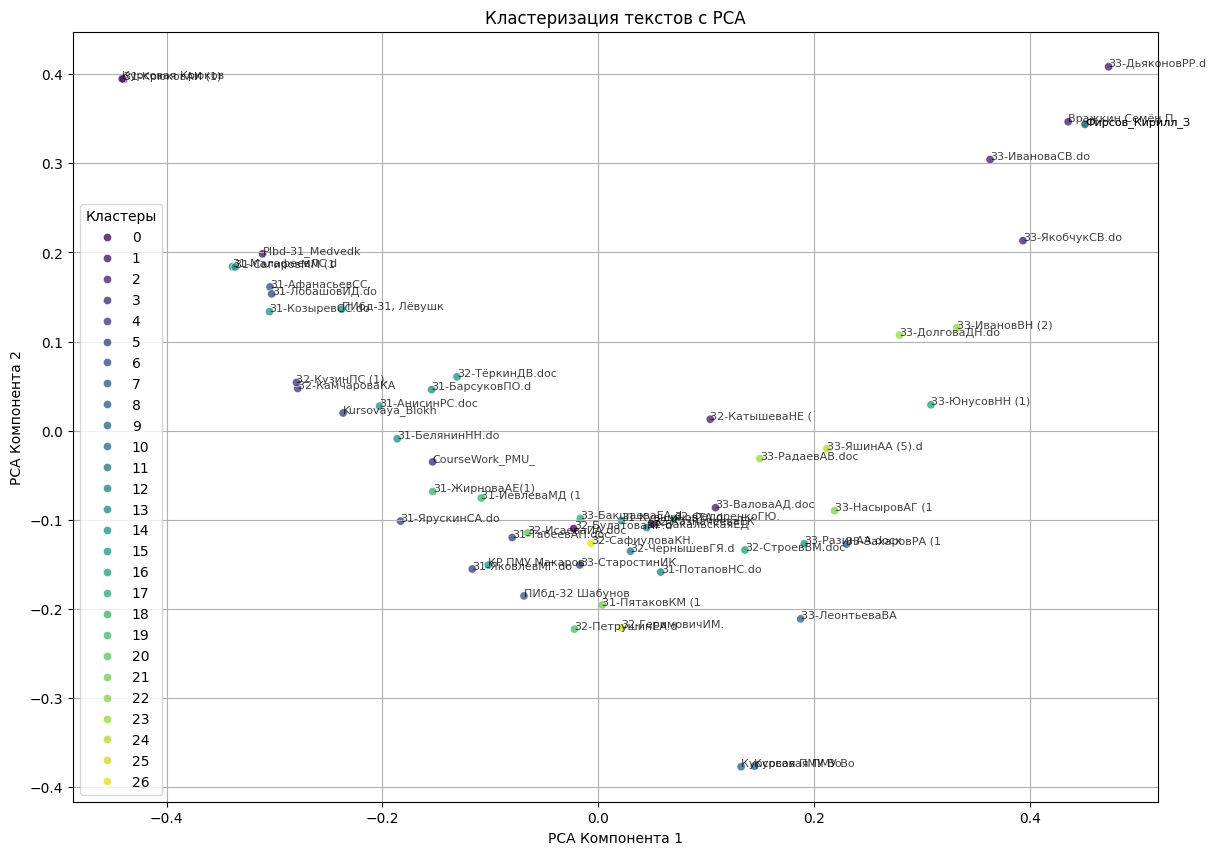

In [128]:
import seaborn as sns

# Создаем DataFrame
cluster_df = pd.DataFrame(X_pca, columns=["PCA1", "PCA2"])
cluster_df["Cluster"] = clusters
cluster_df["Document"] = df["doc"]

plt.figure(figsize=(14, 10))
palette = sns.color_palette("viridis", n_clusters)
sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette=palette,
    data=cluster_df,
    legend="full",
    alpha=0.8
)

# Подписи документов
for i in range(len(cluster_df)):
    plt.text(
        cluster_df["PCA1"].iloc[i],
        cluster_df["PCA2"].iloc[i],
        cluster_df["Document"].iloc[i][:15],  # Обрезаем текст для читаемости
        fontsize=8,
        alpha=0.75
    )

plt.title("Кластеризация текстов с PCA")
plt.xlabel("PCA Компонента 1")
plt.ylabel("PCA Компонента 2")
plt.legend(title="Кластеры")
plt.grid(True)
plt.show()


### Отображение результата кластеризации  

Используется косинусовое сходство для определения схожих работ. Проверка сходимости до 70% совпадений

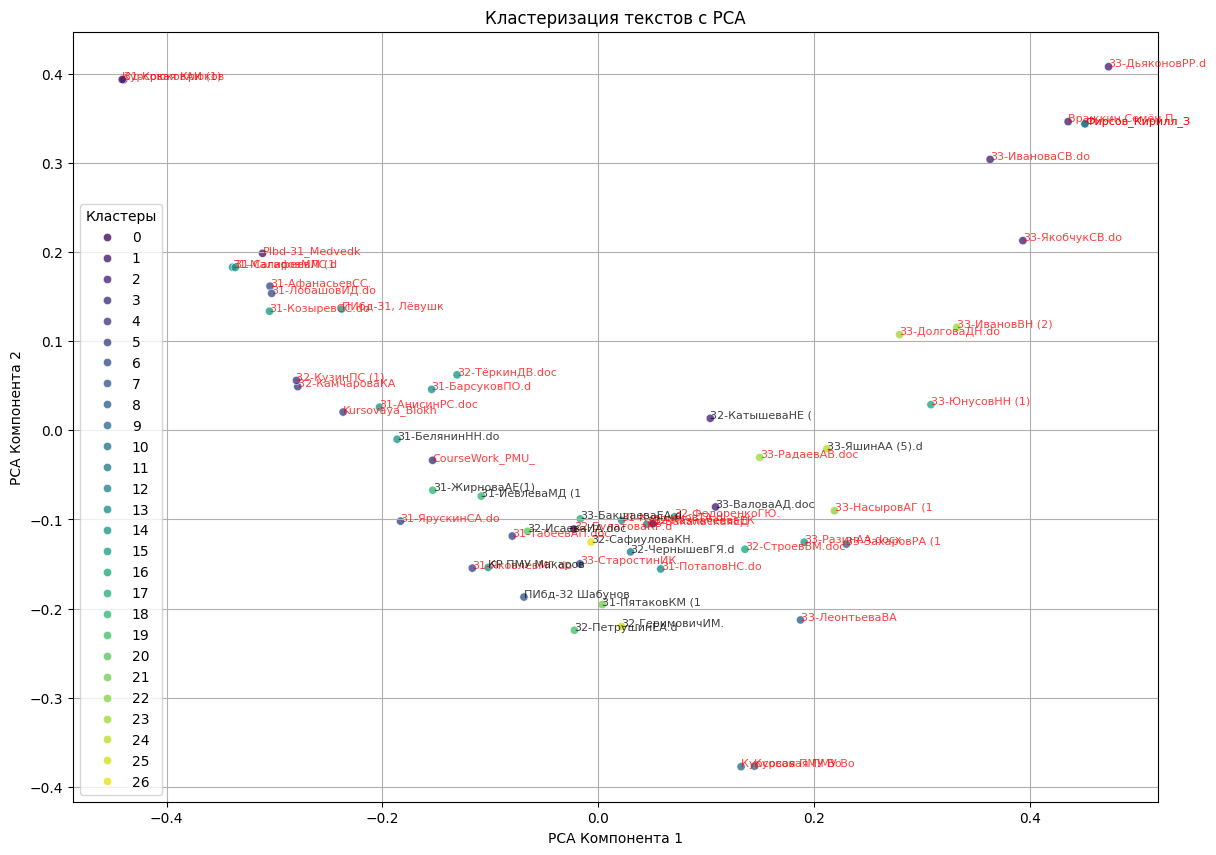

In [129]:
from sklearn.metrics.pairwise import cosine_similarity

# Задаём количество кластеров
n_clusters = 27

# Создаём модель K-Means 
kmeans = KMeans(n_clusters=n_clusters, random_state=42)

# Обучаем модель и предсказываем кластеры
clusters = kmeans.fit_predict(tfidf_matrix)

# Уменьшаем размерность данных до 2 компонент с помощью PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(tfidf_matrix.toarray())

# Создаем DataFrame
cluster_df = pd.DataFrame(X_pca, columns=["PCA1", "PCA2"])
cluster_df["Cluster"] = clusters
cluster_df["Document"] = df["doc"]

# Вычисляем косинусное сходство
similarities = cosine_similarity(tfidf_matrix)

plt.figure(figsize=(14, 10))
palette = sns.color_palette("viridis", n_clusters)
sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette=palette,
    data=cluster_df,
    legend="full",
    alpha=0.8
)

# Подписи документов и выделение схожих кластеров
threshold = 0.3  # Порог для определения схожести
for i in range(len(cluster_df)):
    similar_docs = [j for j in range(len(cluster_df)) if similarities[i, j] > threshold and i != j]
    color = "red" if similar_docs else "black"
    plt.text(
        cluster_df["PCA1"].iloc[i],
        cluster_df["PCA2"].iloc[i],
        cluster_df["Document"].iloc[i][:15],  # Обрезаем текст для читаемости
        fontsize=8,
        alpha=0.75,
        color=color
    )

plt.title("Кластеризация текстов с PCA")
plt.xlabel("PCA Компонента 1")
plt.ylabel("PCA Компонента 2")
plt.legend(title="Кластеры")
plt.grid(True)
plt.show()


### Отображение результатов иерархической кластеризации

Силуэт-коэффициент: 0.14697162326273597


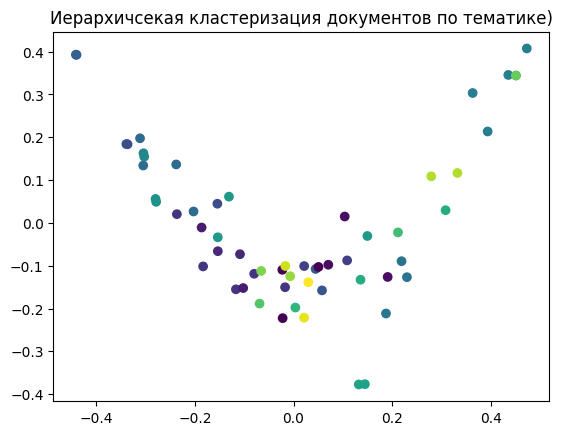

In [130]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Кластеризация с использованием иерархической кластеризации
n_clusters = 27  
hierarchical_clustering = AgglomerativeClustering(n_clusters=n_clusters)
hierarchical_clustering.fit(tfidf_matrix.toarray())  # Преобразуем X_tfidf в массив, если это необходимо

# Получение меток кластеров
cluster_labels = hierarchical_clustering.labels_

# Оценка качества кластеризации
silhouette_avg = silhouette_score(tfidf_matrix.toarray(), cluster_labels)  # Преобразуем X_tfidf в массив
print(f"Силуэт-коэффициент: {silhouette_avg}")

# Визуализация кластеров
pca = PCA(n_components=2)  
X_pca = pca.fit_transform(tfidf_matrix.toarray())

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis')
plt.title("Иерархичсекая кластеризация документов по тематике)")
plt.show()

Силуэт-коэффициент располагается между 0 и 1, что показывает, что объекты находятся на границах кластеров

Таким образом, обучив модель, мы смогли построить систему антиплагиата, которая способна выявлять схожие по содержанию работы. Она обучена опознавать копии и очень похожие по структуре и содержанию работы.  

Как-то так... :)